In [1]:
from truncation_v_learnability_2023_08_08 import output_dir
import pandas as pd
import numpy as np
from misc_utils import read_json_dir_to_df
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = read_json_dir_to_df(output_dir)

In [3]:
df.groupby("system")["run"].max()

system
HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1       9
HeisenbergJ1J2-TriangleLattice6x4-1.0-1.3-True-1    11
Name: run, dtype: int64

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


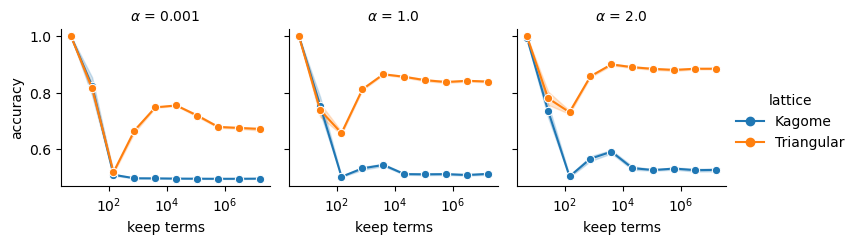

In [8]:
# log x scale
sns.relplot(
    # df.query("alpha == 2"),
    df.rename(
        columns={
            "alpha": r"$\alpha$",
            "keep_terms": "keep terms",
            "test_accuracy": "accuracy",
        }
    ).replace({"lattice": {"KagomeLattice2x4": "Kagome", "TriangleLattice6x4": "Triangular"}}),
    x="keep terms",
    y="accuracy",
    hue="lattice",
    kind="line",
    markers=["o", "o"],
    style="lattice",
    dashes=False,
    col=r"$\alpha$",
    height=2.5,
).set(xscale="log")
plt.savefig("fig/truncation_v_learnability_2023_08_08.pdf")